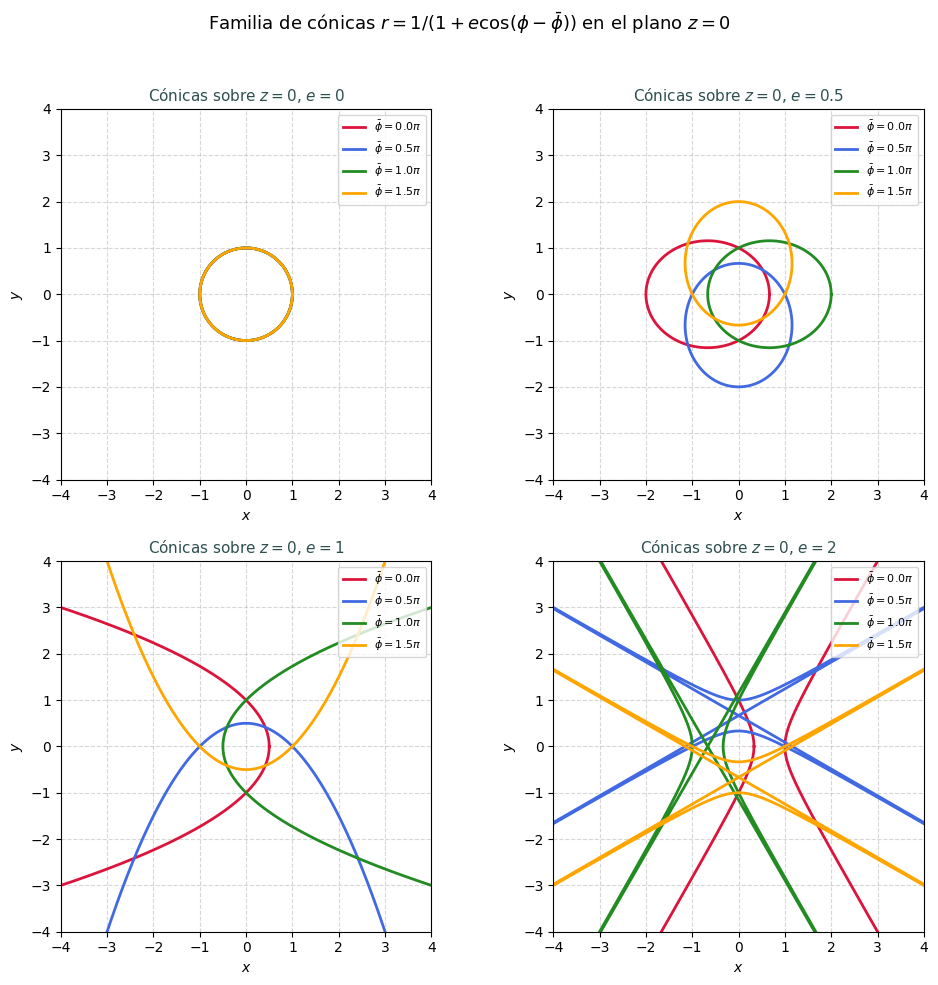

In [1]:
# ====================================================
#  Cónicas sobre el plano z=0
#  r = 1 / (1 + e*cos(phi - phi_bar))
# ====================================================

import numpy as np
import matplotlib.pyplot as plt

# --- Definición de la ecuación polar ---
def conica(e, phi_bar, n=1000):
    phi = np.linspace(0, 2*np.pi, n)
    denom = 1 + e*np.cos(phi - phi_bar)
    # Evitamos divisiones por cero (hipérbolas/parábolas)
    denom[np.isclose(denom, 0)] = np.nan
    r = 1 / denom
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    return x, y

# --- Parámetros del problema ---
e_values = [0, 0.5, 1, 2]
phi_bars = [0, np.pi/2, np.pi, 3*np.pi/2]
colores = ['crimson', 'royalblue', 'forestgreen', 'orange']

# --- Figura general ---
fig, axes = plt.subplots(2, 2, figsize=(10, 10), subplot_kw={'aspect': 'equal'})
axes = axes.flatten()

for i, e in enumerate(e_values):
    ax = axes[i]
    for j, phi_bar in enumerate(phi_bars):
        x, y = conica(e, phi_bar)
        ax.plot(x, y, lw=2, color=colores[j], label=fr'$\bar{{\phi}} = {phi_bars[j]/np.pi:.1f}\pi$')
    
    ax.set_title(fr'Cónicas sobre $z=0$, $e={e}$', fontsize=11, color='darkslategray')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, ls='--', alpha=0.5)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)

plt.suptitle('Familia de cónicas $r = 1/(1 + e\\cos(\\phi - \\bar{\\phi}))$ en el plano $z=0$', fontsize=13)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

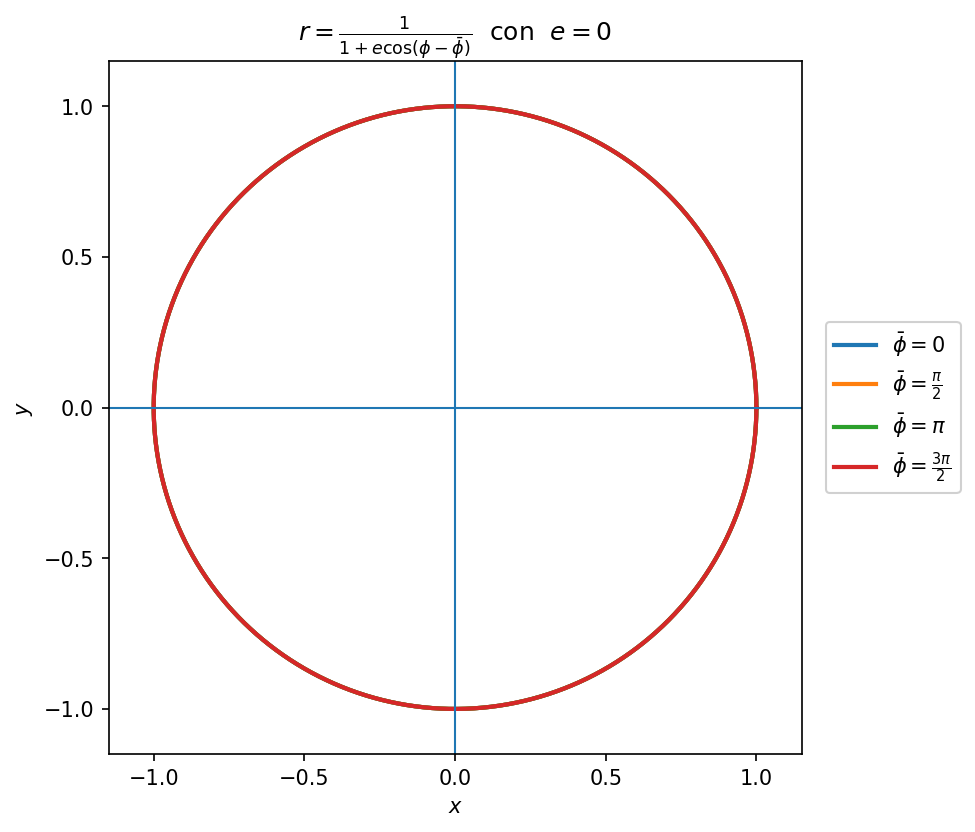

In [2]:
# e = 0 (circunferencia), guarda: conica_e_0_0.png
import numpy as np
import matplotlib.pyplot as plt

e = 0.0
phibars = [0.0, np.pi/2, np.pi, 3*np.pi/2]
labels  = [r"$\bar{\phi}=0$", r"$\bar{\phi}=\frac{\pi}{2}$", r"$\bar{\phi}=\pi$", r"$\bar{\phi}=\frac{3\pi}{2}$"]

phi = np.linspace(0, 2*np.pi, 3600, endpoint=False)
eps = 1e-6

fig, ax = plt.subplots(figsize=(6,6), dpi=150)
fig.patch.set_alpha(0.0); ax.patch.set_alpha(0.0)

allx, ally = [], []
for phibar, lab in zip(phibars, labels):
    denom = 1 + e*np.cos(phi - phibar)
    mask = np.abs(denom) > eps
    # segmentar para no unir a través de huecos
    idx = np.where(np.diff(mask.astype(int)) != 0)[0]
    starts = np.r_[0, idx+1]; ends = np.r_[idx+1, len(mask)]
    first=True
    for s,t in zip(starts, ends):
        m = mask[s:t]
        if not m.any(): continue
        ph = phi[s:t][m]; d = denom[s:t][m]
        r = 1.0/d; x = r*np.cos(ph); y = r*np.sin(ph)
        allx.append(x); ally.append(y)
        ax.plot(x, y, lw=2, label=lab if first else None); first=False

ax.set_aspect('equal', adjustable='box')
xcat = np.concatenate(allx); ycat = np.concatenate(ally)
finite = np.isfinite(xcat) & np.isfinite(ycat)
xcat = xcat[finite]; ycat = ycat[finite]
R = max(np.percentile(np.abs(xcat), 99), np.percentile(np.abs(ycat), 99))
R = 1.0 if R == 0 else R
m = 0.15*R; lim = R+m
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

ax.axhline(0, lw=1); ax.axvline(0, lw=1)
ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$y$")
ax.set_title(r"$r=\frac{1}{1+e\cos(\phi-\bar{\phi})}$  con  $e=0$")
ax.legend(loc="center left", bbox_to_anchor=(1.02,0.5), framealpha=0.9)

plt.savefig("conica_e_0_0.png", dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.08)
plt.show()


In [12]:
# --- Utilidades compartidas: paletas, grilla polar y trazador de cónicas ---
import numpy as np
import matplotlib.pyplot as plt

# Paletas disponibles (elige por nombre)
PALETAS = {
    "classic": ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"],           # azul, rojo, verde, naranja
    "bright":  ["#3366FF", "#FF3366", "#33CC66", "#FFCC33"],           # vivos
    "muted":   ["#4C78A8", "#F58518", "#54A24B", "#B279A2"],           # tonos tenues
    "cb_safe": ["#0072B2", "#E69F00", "#009E73", "#D55E00"],           # colorblind-friendly
    "pastel":  ["#8ecae6", "#ffb703", "#219ebc", "#fb8500"],           # pasteles sobrios
}

def draw_polar_grid(ax, rmax, rings=None, ray_step_deg=30, color="0.8"):
    """
    Dibuja grilla polar en el eje ax:
      - anillos: lista de radios (si None, genera automáticamente)
      - ray_step_deg: separación angular entre rayos en grados
      - color: tono gris (o hex) para la grilla
    """
    if rings is None:
        # 6 anillos espaciados hasta rmax
        base = np.linspace(rmax/6, rmax, 6)
        rings = np.round(base, 2)

    ang = np.linspace(0, 2*np.pi, 721)
    for rho in rings:
        x = rho*np.cos(ang)
        y = rho*np.sin(ang)
        ax.plot(x, y, color=color, lw=0.6)

    for a_deg in range(0, 360, ray_step_deg):
        a = np.deg2rad(a_deg)
        ax.plot([0, rmax*np.cos(a)], [0, rmax*np.sin(a)], color=color, lw=0.6)

def plot_conic_family_with_polar_grid(e, palette="classic", filename="conica.png",
                                      dpi=300, phi_samples=6000, eps=1e-3,
                                      rmax_hint=None, title=None, show=True):
    """
    Traza la familia para un e dado con grilla polar y guarda PNG transparente.
    - palette: nombre en PALETAS
    - eps: umbral para cortar singularidades (aumenta para e grandes)
    - rmax_hint: si lo das, fija el tamaño del lienzo (útil e=1 y e=2)
    """
    phibars = [0.0, np.pi/2, np.pi, 3*np.pi/2]
    labels  = [r"$\bar{\phi}=0$", r"$\bar{\phi}=\frac{\pi}{2}$",
               r"$\bar{\phi}=\pi$", r"$\bar{\phi}=\frac{3\pi}{2}$"]
    colors = PALETAS.get(palette, PALETAS["classic"])

    phi = np.linspace(0, 2*np.pi, phi_samples, endpoint=False)

    fig, ax = plt.subplots(figsize=(6,6), dpi=dpi)
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    allx, ally = [], []
    for (phibar, lab, col) in zip(phibars, labels, colors):
        denom = 1.0 + e*np.cos(phi - phibar)
        mask = np.abs(denom) > eps

        # segmentar para no unir a través de huecos
        idx = np.where(np.diff(mask.astype(int)) != 0)[0]
        starts = np.r_[0, idx+1]
        ends   = np.r_[idx+1, len(mask)]
        first = True
        for s, t in zip(starts, ends):
            m = mask[s:t]
            if not m.any(): continue
            ph = phi[s:t][m]
            r  = 1.0 / (1.0 + e*np.cos(ph - phibar))
            x, y = r*np.cos(ph), r*np.sin(ph)
            allx.append(x); ally.append(y)
            ax.plot(x, y, color=col, lw=2, label=lab if first else None)
            first = False

    # límites y grilla polar
    ax.set_aspect("equal", adjustable="box")
    if allx:
        xcat = np.concatenate(allx); ycat = np.concatenate(ally)
        finite = np.isfinite(xcat) & np.isfinite(ycat)
        xcat, ycat = xcat[finite], ycat[finite]
        if rmax_hint is None and xcat.size:
            # usa percentiles para evitar extremos por singularidades
            rmax = max(np.percentile(np.abs(xcat), 98.5), np.percentile(np.abs(ycat), 98.5))
        else:
            rmax = float(rmax_hint)
    else:
        rmax = 2.0
    rmax = max(rmax, 1.0)
    margin = 0.10*rmax
    ax.set_xlim(-rmax-margin, rmax+margin)
    ax.set_ylim(-rmax-margin, rmax+margin)

    # grilla polar "a mano"
    draw_polar_grid(ax, rmax=rmax, rings=None, ray_step_deg=30, color="0.85")

    # ejes y estilo "polar"
    ax.axhline(0, color="0.25", lw=1)
    ax.axvline(0, color="0.25", lw=1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$y$")
    if title is None:
        title = rf"$r=\frac{{1}}{{1+e\cos(\phi-\bar{{\phi}})}}$  con  $e={e}$"
    ax.set_title(title)

    ax.legend(loc="center left", bbox_to_anchor=(1.03,0.5), framealpha=0.9)

    plt.savefig(filename, dpi=dpi, transparent=True, bbox_inches="tight", pad_inches=0.08)
    if show:
        plt.show()
    else:
        plt.close(fig)


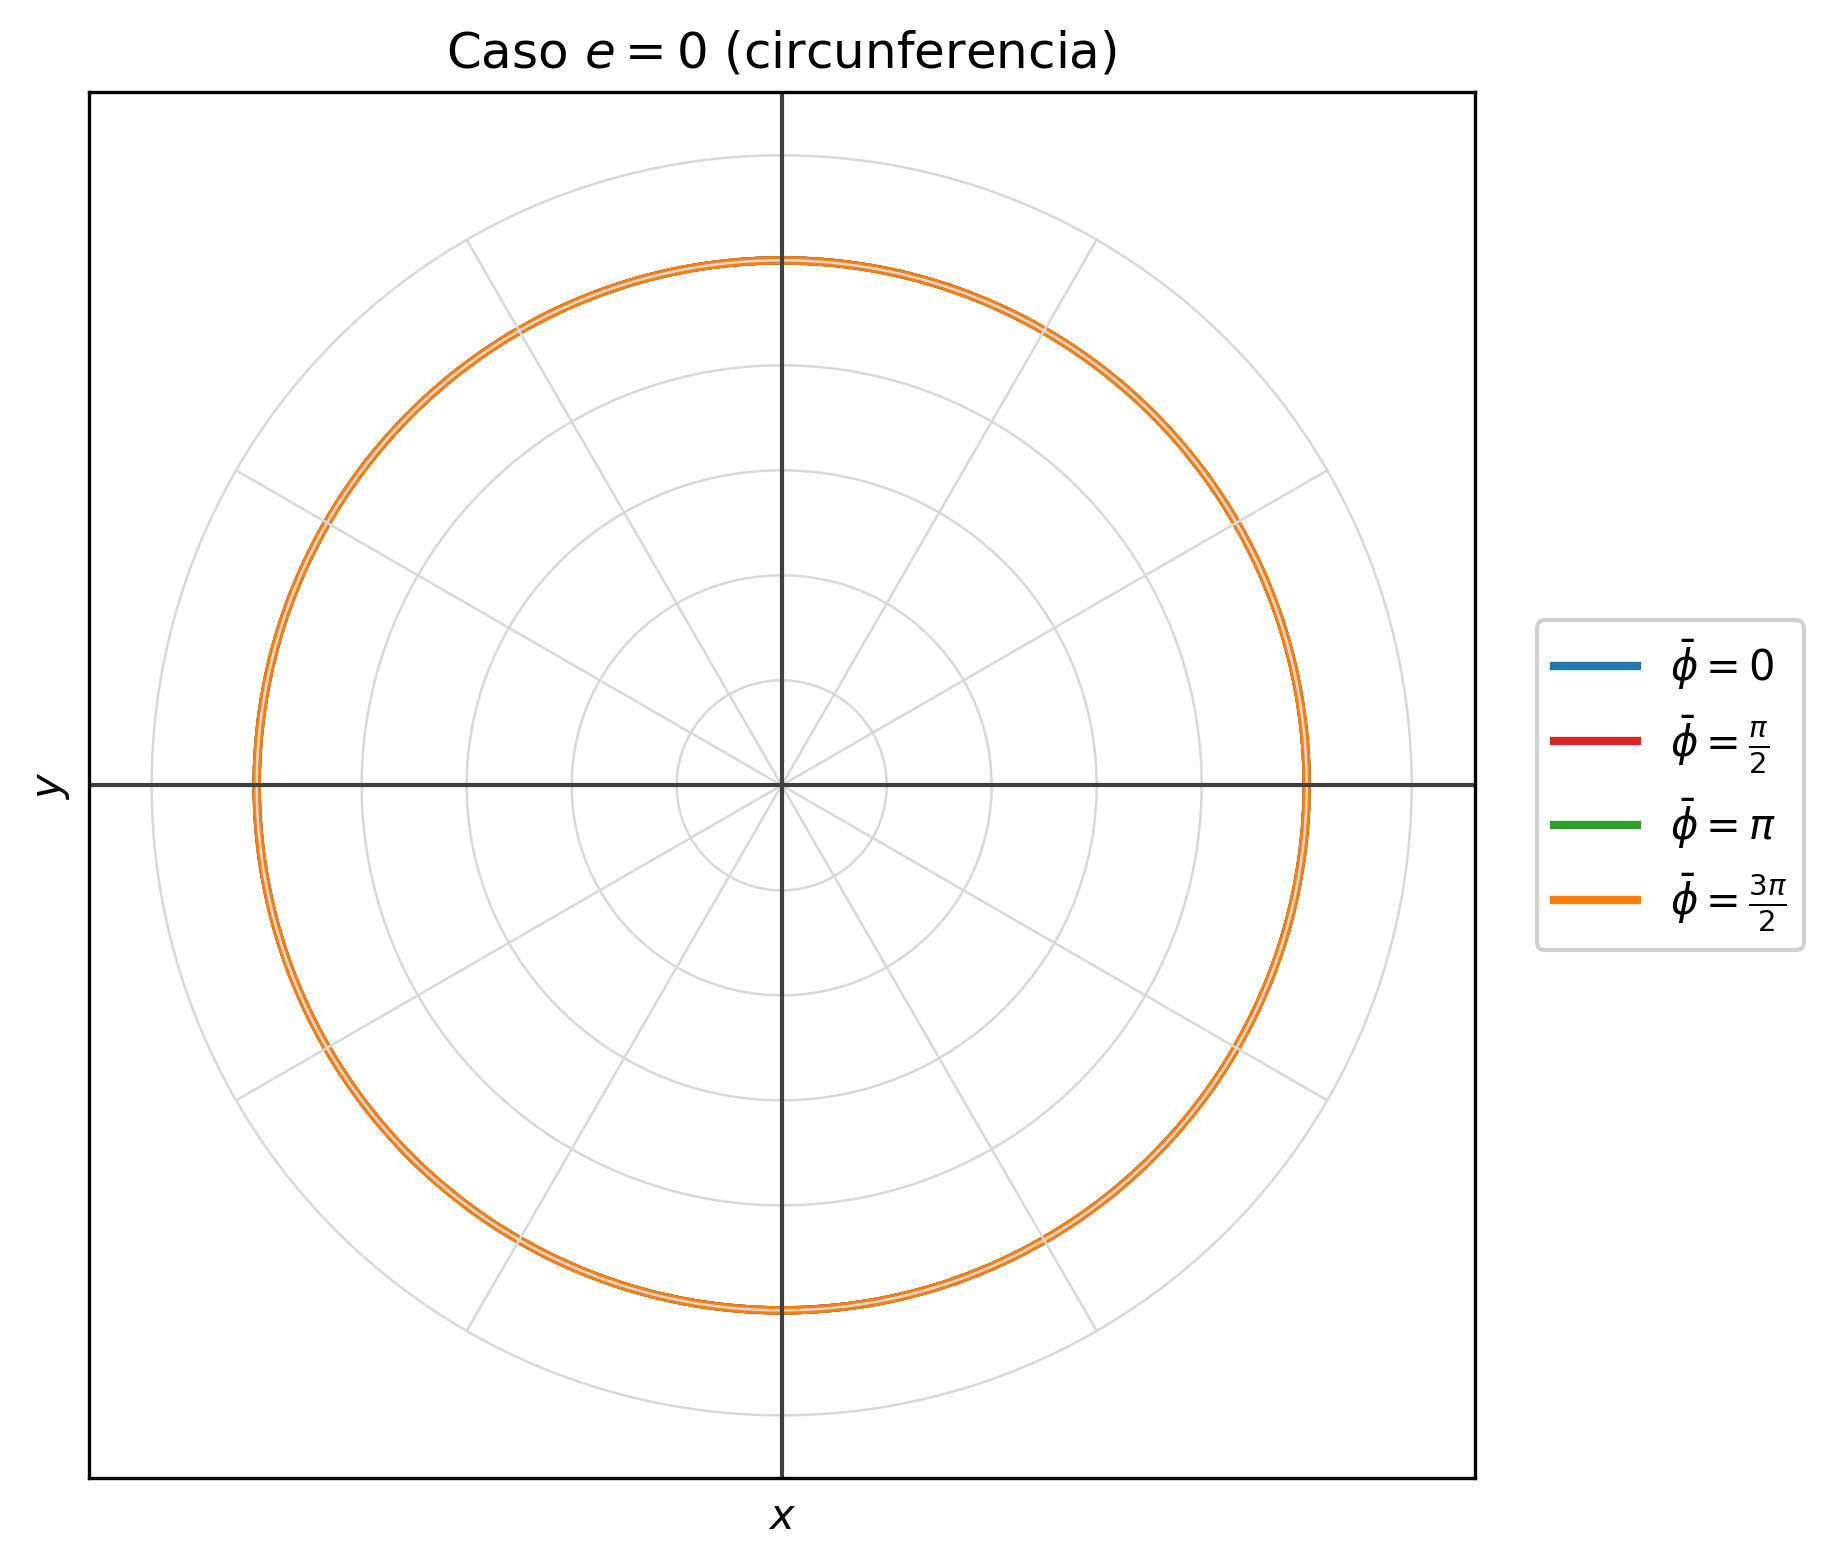

In [13]:
plot_conic_family_with_polar_grid(
    e=0.0,
    palette="classic",                 # cambia aquí la paleta
    filename="conica_e_0_0.png",
    dpi=300,
    phi_samples=3600,
    eps=1e-6,
    rmax_hint=1.2,                     # radio ~1, un poco de margen
    title=r"Caso $e=0$ (circunferencia)"
)


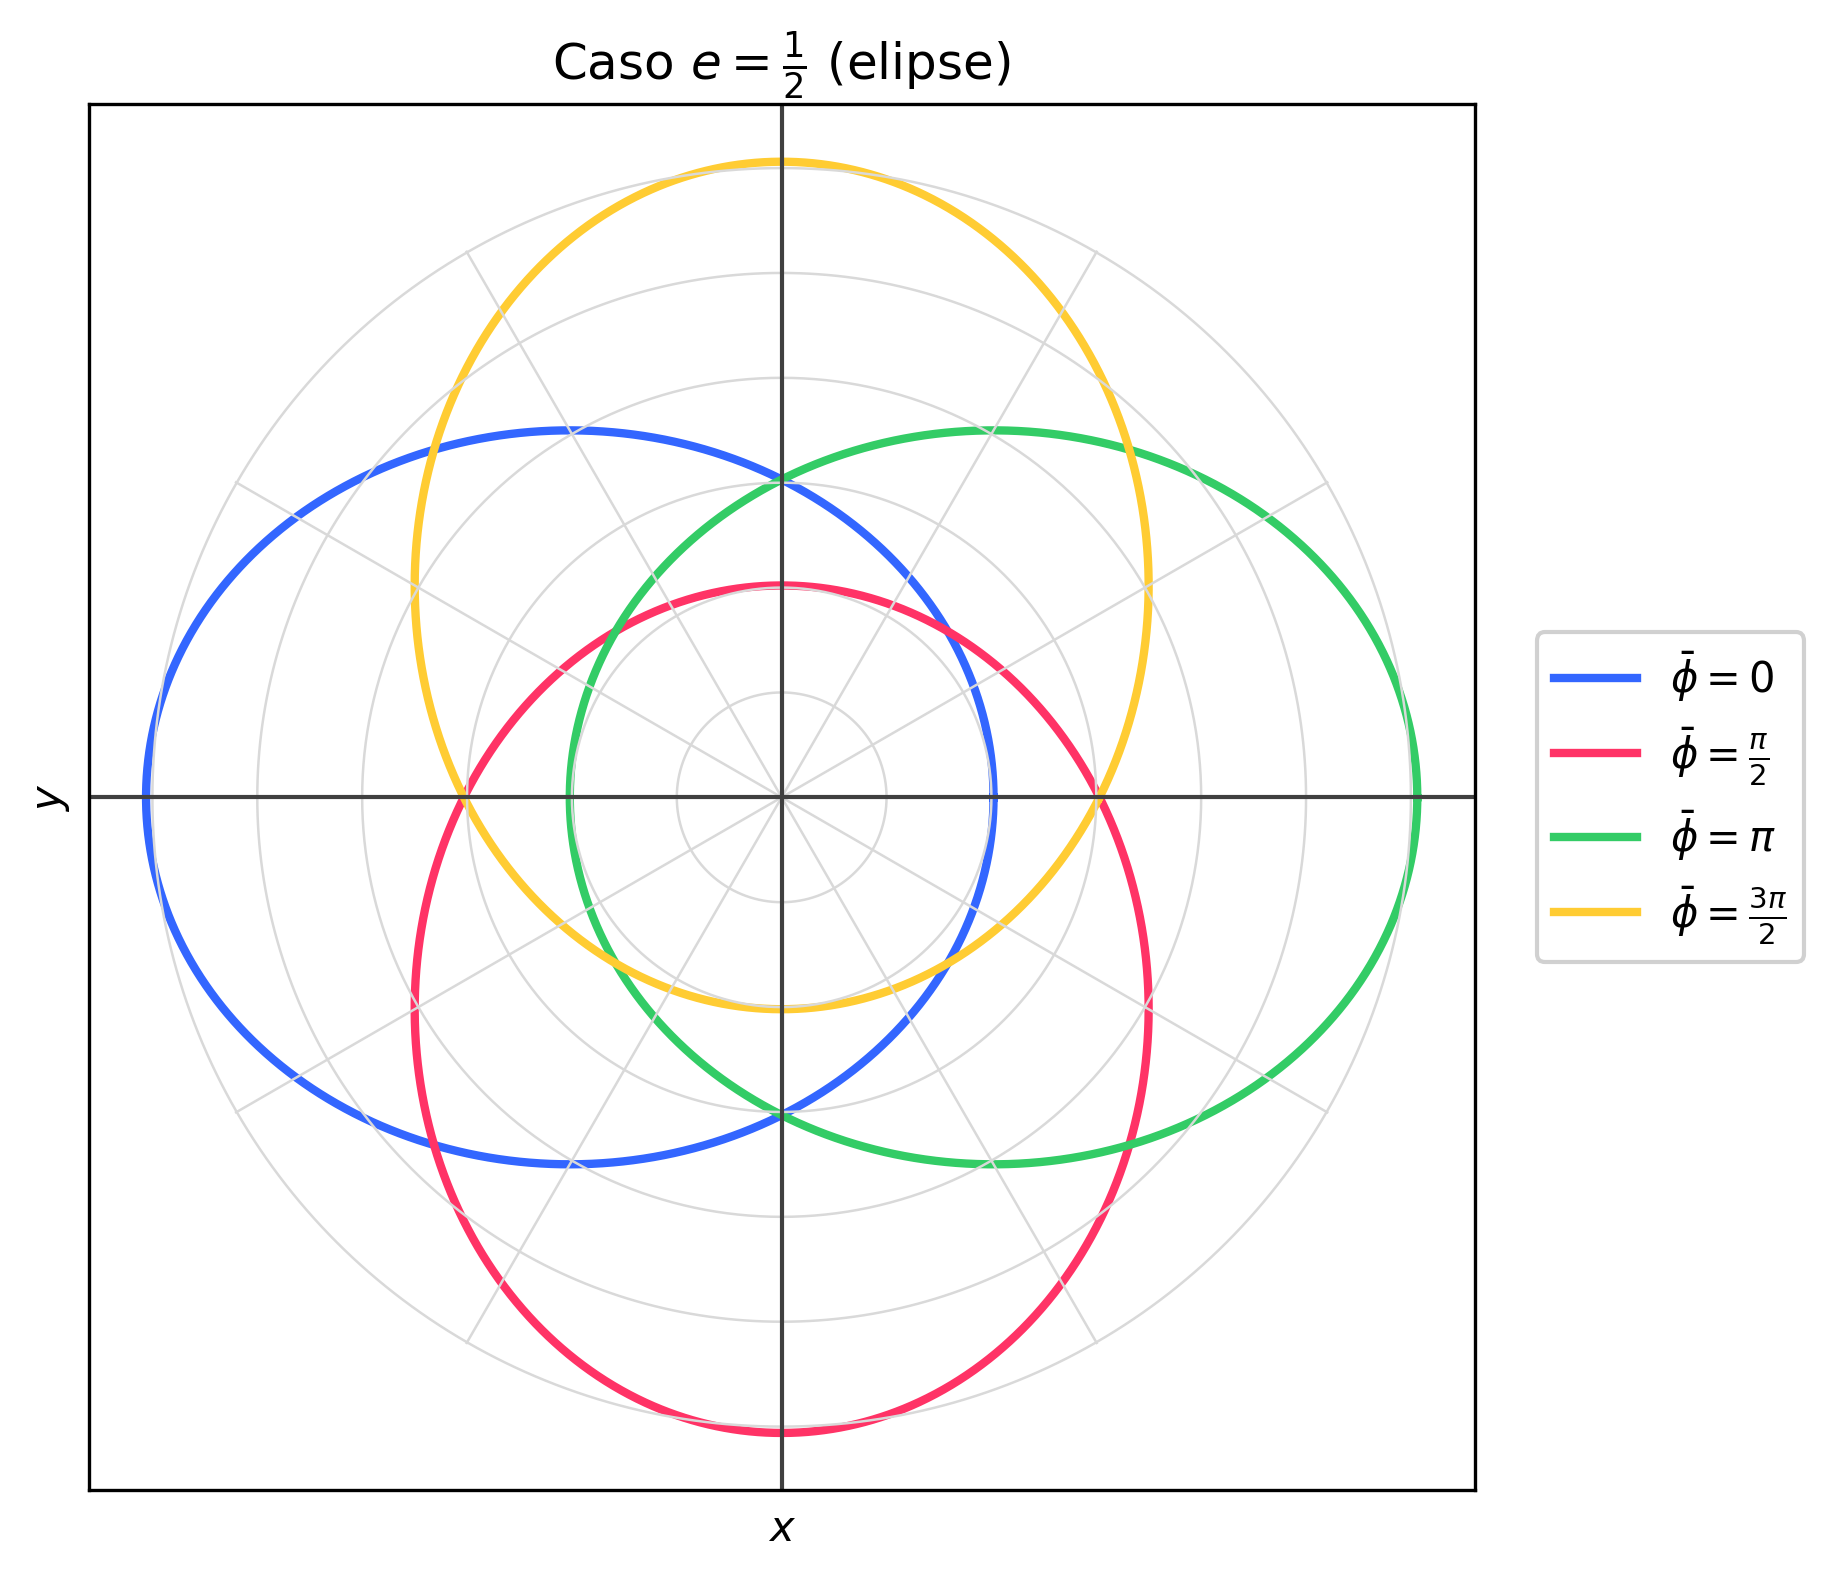

In [14]:
plot_conic_family_with_polar_grid(
    e=0.5,
    palette="bright",                  # otra paleta
    filename="conica_e_0_5.png",
    dpi=300,
    phi_samples=4800,
    eps=1e-6,
    rmax_hint=None,                    # auto
    title=r"Caso $e=\frac{1}{2}$ (elipse)"
)


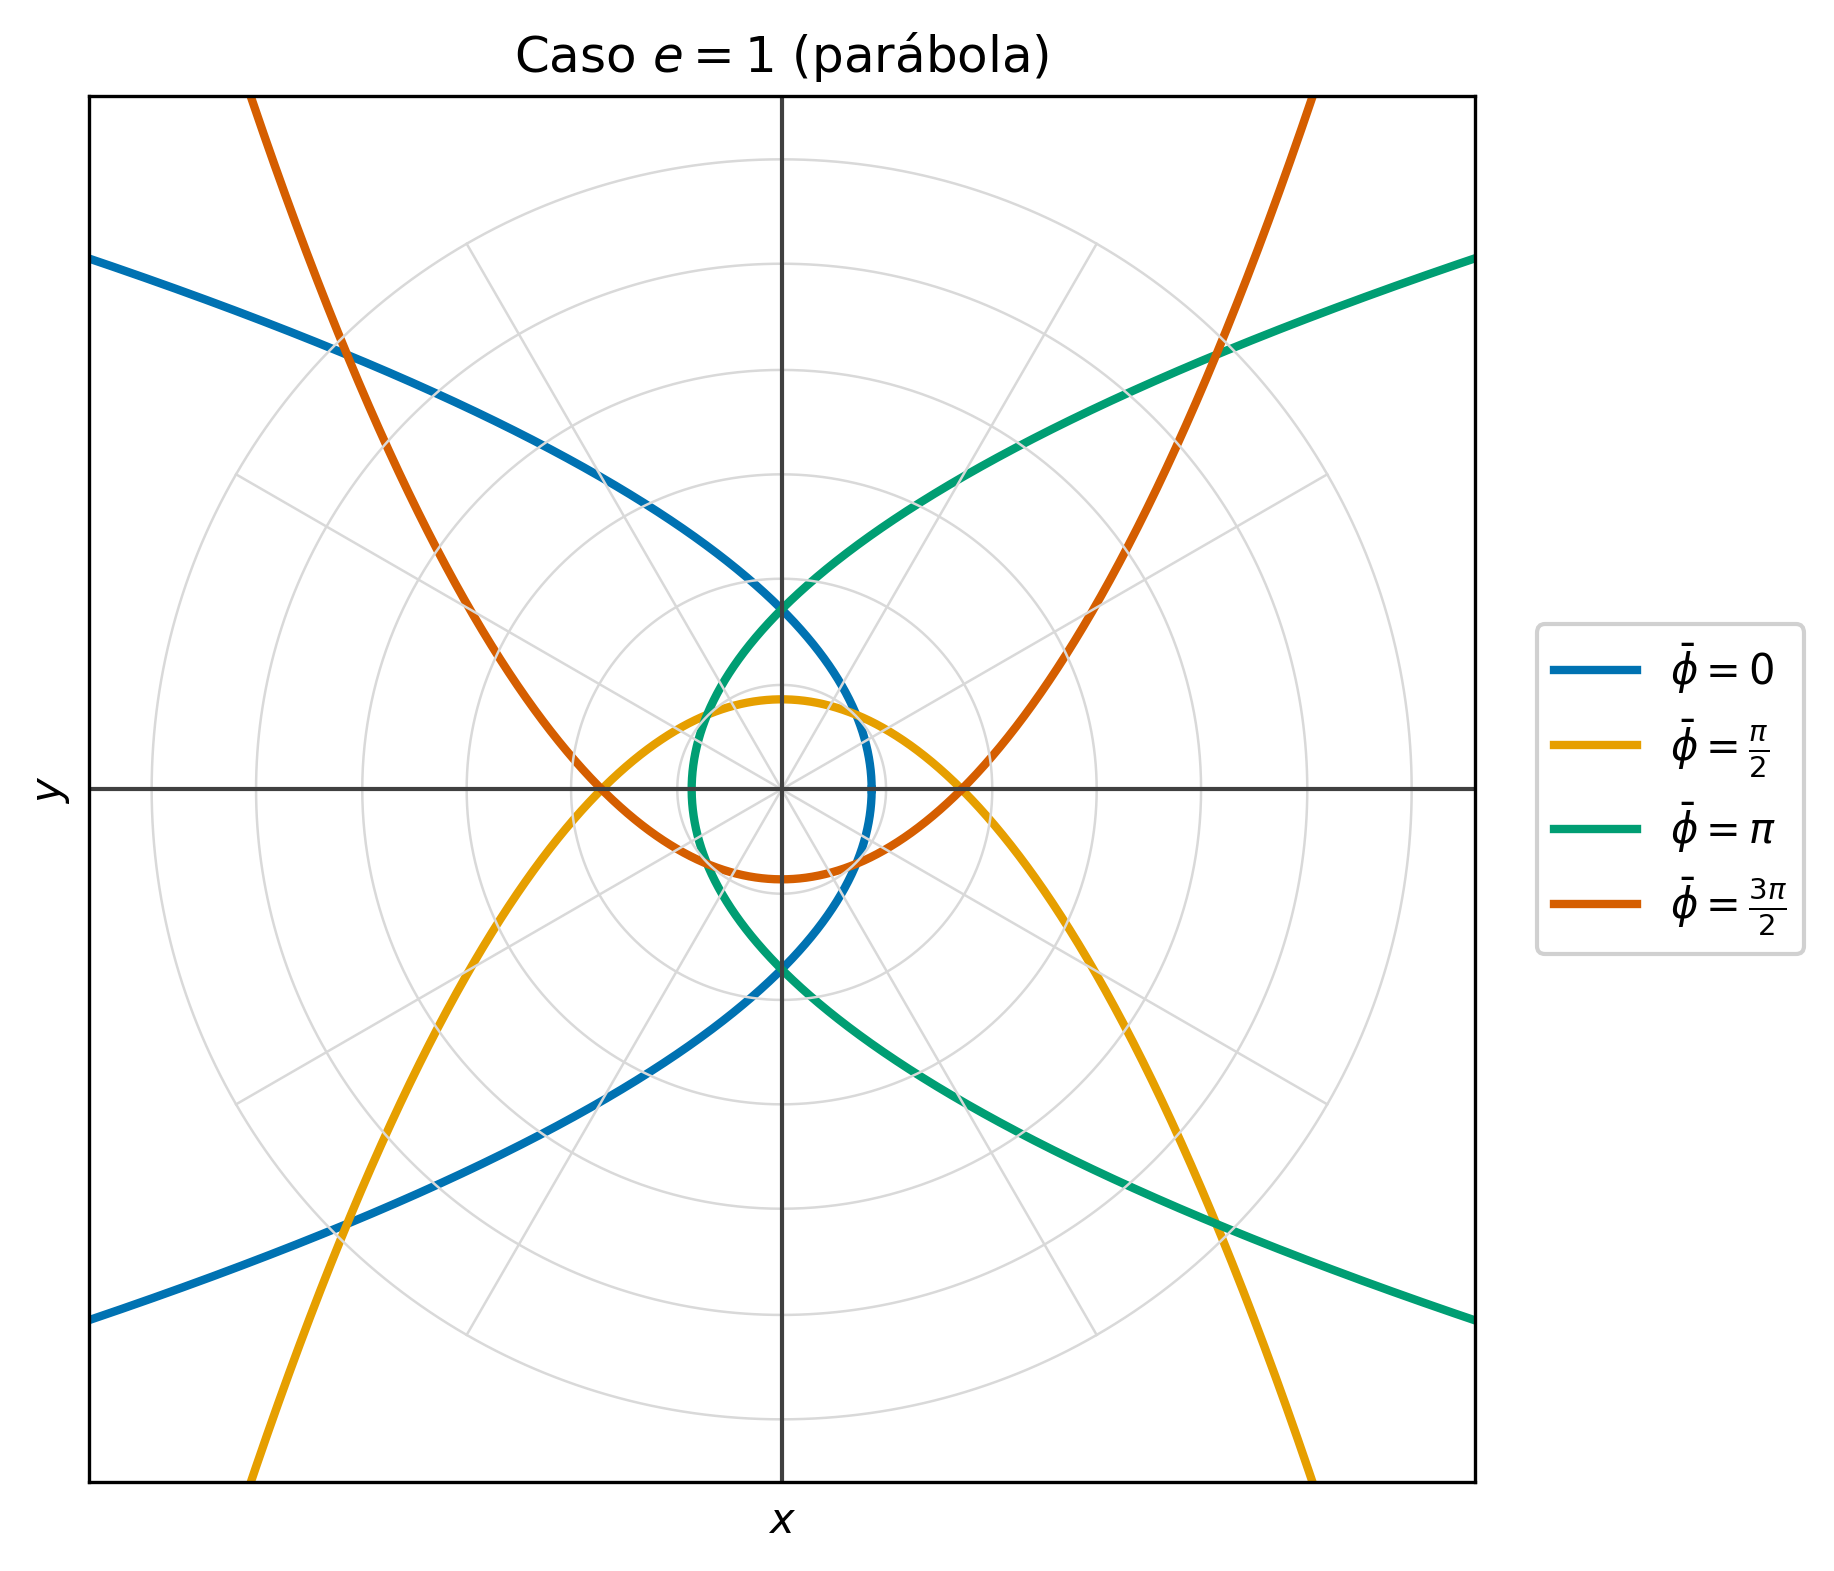

In [6]:
plot_conic_family_with_polar_grid(
    e=1.0,
    palette="cb_safe",                 # paleta apta para daltónicos
    filename="conica_e_1_0.png",
    dpi=300,
    phi_samples=7000,
    eps=2e-3,                          # recorte mayor por singularidad
    rmax_hint=3.5,                     # abre más la ventana
    title=r"Caso $e=1$ (parábola)"
)


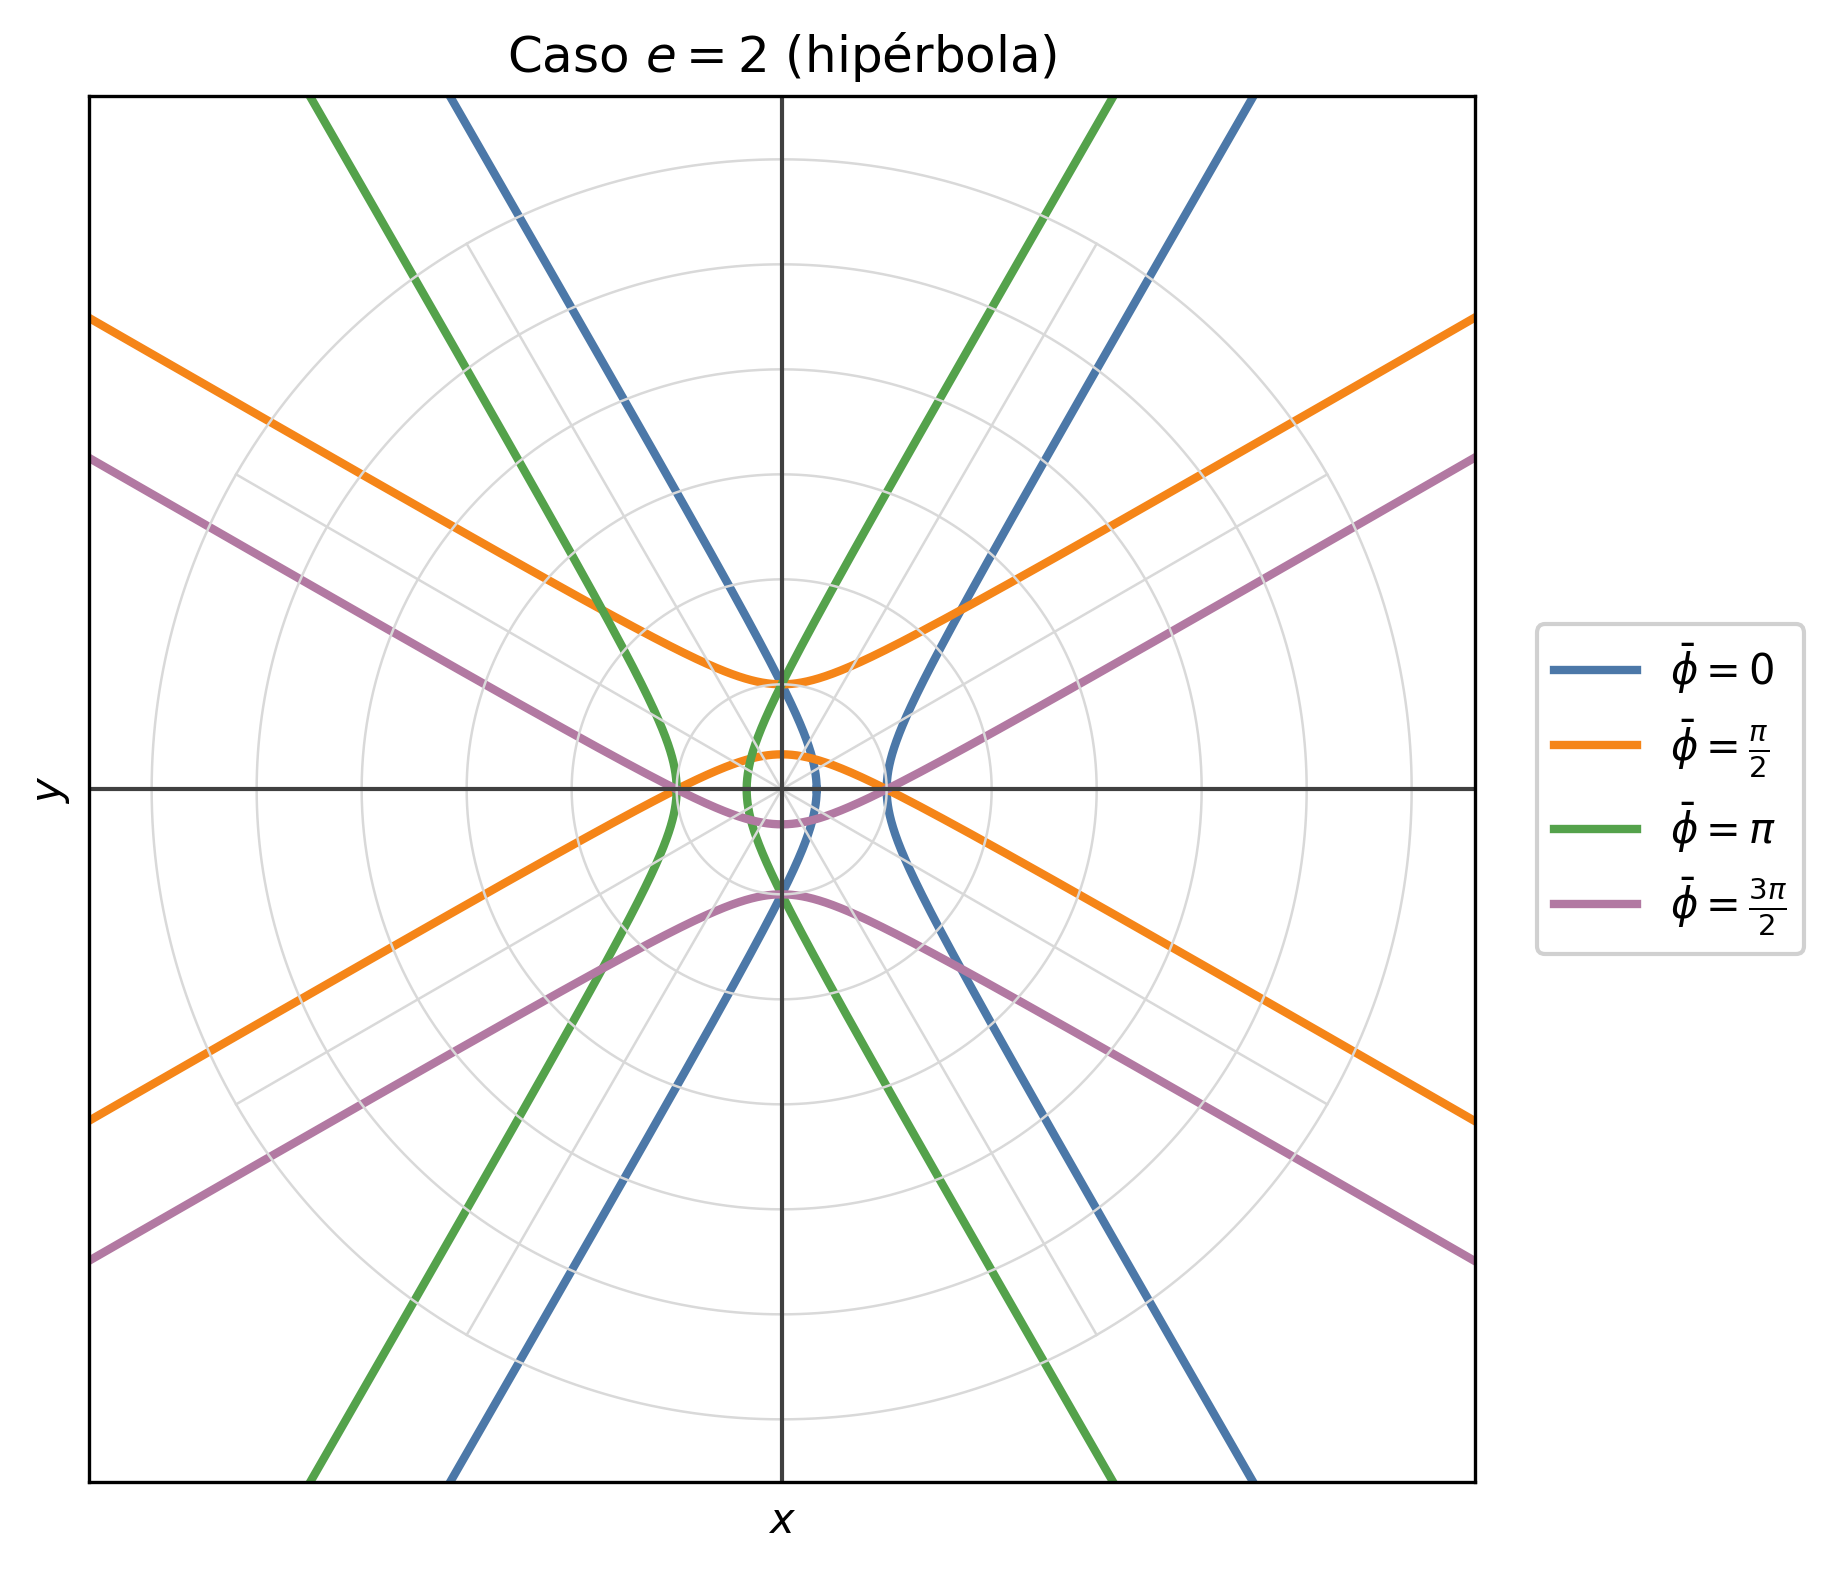

In [7]:
plot_conic_family_with_polar_grid(
    e=2.0,
    palette="muted",                   # otra paleta
    filename="conica_e_2_0.png",
    dpi=300,
    phi_samples=9000,
    eps=4e-3,                          # recorte más agresivo
    rmax_hint=6.0,                     # ventana amplia
    title=r"Caso $e=2$ (hipérbola)"
)
